<a href="https://colab.research.google.com/github/Ritesh1435/House-price/blob/main/Flipkart_Reviews_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install pandas numpy nltk scikit-learn seaborn matplotlib

In [5]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [7]:
from google.colab import files
uploaded = files.upload()

Saving flipkart.csv to flipkart (1).csv


In [12]:
import io

df = pd.read_csv(io.BytesIO(uploaded['flipkart (1).csv']))
df.head()

,Unnamed: 0,Product_name,Review,Rating
0,0,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Best under 60k Great performanceI got it for a...,5
1,1,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Good perfomence...,5
2,2,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Great performance but usually it has also that...,5
3,3,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,My wife is so happy and best product 👌🏻😘,5
4,4,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Light weight laptop with new amazing features,...",5


In [13]:
#Create Sentiment Column (IMPORTANT)
# here what we done is loop we hvve give f rating above 4 the it will positive less then it will be negative
def get_sentiment(rating):
    if rating >= 4:
        return "positive"
    else:
        return "negative"

df["sentiment"] = df["Rating"].apply(get_sentiment)
df.head()

,Unnamed: 0,Product_name,Review,Rating,sentiment
0,0,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Best under 60k Great performanceI got it for a...,5,positive
1,1,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Good perfomence...,5,positive
2,2,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Great performance but usually it has also that...,5,positive
3,3,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,My wife is so happy and best product 👌🏻😘,5,positive
4,4,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Light weight laptop with new amazing features,...",5,positive


In [14]:
# Text Cleaning
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.split()
    text = [word for word in text if word not in stop_words]
    return " ".join(text)

df["clean_review"] = df["Review"].apply(clean_text)

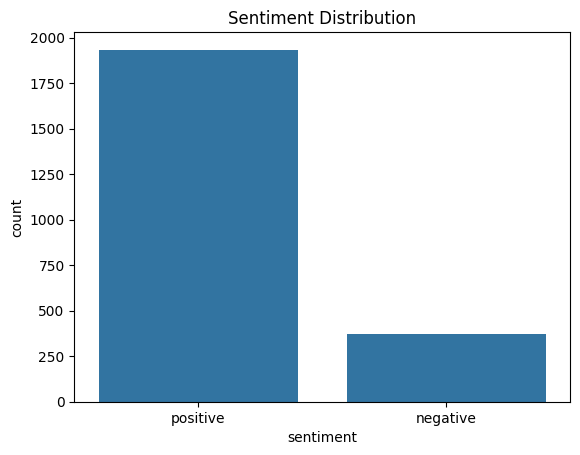

In [15]:
# Data Visualization
sns.countplot(x=df["sentiment"])
plt.title("Sentiment Distribution")
plt.show()

In [16]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["clean_review"]).toarray()
y = df["sentiment"]

In [17]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
# Model Training
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [19]:
# Predictions
y_pred = model.predict(X_test)

In [20]:
# Accuracy + Report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9002169197396963
              precision    recall  f1-score   support

    negative       0.92      0.34      0.50        67
    positive       0.90      0.99      0.94       394

    accuracy                           0.90       461
   macro avg       0.91      0.67      0.72       461
weighted avg       0.90      0.90      0.88       461



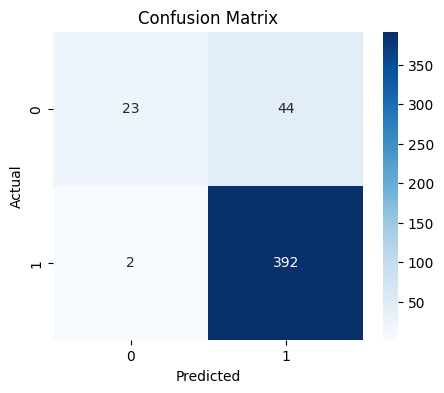

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [22]:
def predict_sentiment(review):
    review = clean_text(review)
    vector = tfidf.transform([review]).toarray()
    return model.predict(vector)[0]

print(predict_sentiment("This laptop is amazing and fast"))
print(predict_sentiment("Very bad product, waste of money"))

positive
negative
